# 🚍 GTFS Diagnostics — versão revisada

Este notebook reorganiza o fluxo analítico em blocos curtos e explícitos.  
O objetivo é manter o caráter exploratório do diagnóstico, mas com duas correções metodológicas centrais:

1. **distância não é aceita cegamente**; o caderno verifica a plausibilidade de `shape_dist_traveled` antes de calcular VKT e velocidade;
2. **corredores** passam a ser apresentados como um **proxy interparadas**, e não como uma geometria física precisa do corredor.

## Estrutura

| # | Seção | Saídas principais |
|---|---|---|
| 0 | Configuração | caminho do feed, janelas horárias, flags |
| 1 | Carga e contexto | feed, data de análise, CRS, viagens ativas |
| 2 | Visão geral e QA de distância | quadro-resumo + checagem de escala |
| 3 | Perfil temporal | viagens ativas ao longo do dia |
| 4 | Paradas | headway, frequência e mapas simples |
| 5 | Sobreposição interparadas | proxy espacial de concentração de serviço |
| 6 | Produção por viagem e por rota | VKT, duração, velocidade e tabelas |
| 7 | Diagnósticos | velocidades, espaçamento, completude |

> Observação: este notebook prioriza **leitura clara** e **honestidade analítica**.  
> Onde a geometria ou a unidade de distância forem incertas, ele sinaliza isso explicitamente.

## 0 — Configuração

In [6]:
GTFS_PATH = "../data/processed/20260325_183744/gtfs.zip"

# None = detectar automaticamente o dia mais movimentado
ANALYSIS_DATE: str | None = None

TIME_WINDOWS = [
    ("Madrugada", "00:00:00", "05:00:00"),
    ("Manhã Pico", "05:00:00", "09:00:00"),
    ("Entrepico", "09:00:00", "16:00:00"),
    ("Tarde Pico", "16:00:00", "20:00:00"),
    ("Noite", "20:00:00", "24:00:00"),
]

HEADWAY_START = "06:00:00"
HEADWAY_END = "08:00:00"

# Defina manualmente se já souber o UTM adequado. None = auto.
LOCAL_CRS: int | None = None

# Se True, o notebook interrompe quando a distância parecer implausível.
STRICT_DISTANCE_SANITY = False

# Mostrar também a leitura desagregada por direction_id nas paradas.
SPLIT_DIRECTIONS_STOPS = False

## 1 — Carga e contexto

In [7]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import sys
from pathlib import Path
sys.path.append(str(Path.cwd()))
import geopandas as gpd

import gtfs_kit as gk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.colors import sample_colorscale
from IPython.display import display

from gtfs_diag_helpers import (
    assign_time_window,
    build_feed_checks,
    build_interstop_proxy,
    build_network_time_series,
    build_overview,
    build_route_summary,
    build_stop_spacing,
    build_stop_stats_gdf,
    build_trip_metrics_raw,
    build_trip_window_summary,
    choose_busiest_date,
    compute_active_trip_ids,
    ensure_shape_dist_traveled,
    finalize_trip_metrics,
    hhmmss_to_hours,
    infer_distance_scale,
    infer_local_crs,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [8]:
feed = gk.read_feed(GTFS_PATH, dist_units="m")
feed = ensure_shape_dist_traveled(feed)

analysis_date = ANALYSIS_DATE or choose_busiest_date(feed)
local_crs = LOCAL_CRS or infer_local_crs(feed)
active_trip_ids = compute_active_trip_ids(feed, analysis_date)

trip_metrics_raw = build_trip_metrics_raw(feed, active_trip_ids)
distance_scale = infer_distance_scale(trip_metrics_raw)
trip_metrics = finalize_trip_metrics(trip_metrics_raw, distance_scale)

if STRICT_DISTANCE_SANITY and distance_scale["status"] == "suspect":
    raise ValueError(distance_scale["message"])

overview_df = build_overview(feed, analysis_date, local_crs, active_trip_ids)

print(f"Feed: {GTFS_PATH}")
print(f"Data de análise: {analysis_date}")
print(f"Viagens ativas: {len(active_trip_ids):,}")
print(f"CRS local: EPSG:{local_crs}")
print(f"Escala adotada para distância: {distance_scale['unit_guess']} (fator {distance_scale['scale_factor']})")

c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\gtfs_kit\trips.py:159: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  f[date] = f["service_id"].isin(active_services).astype(int)
c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\gtfs_kit\trips.py:159: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  f[date] = f["service_id"].isin(active_services).astype(int)
c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\gtfs_kit\trips.py:159: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

Feed: ../data/processed/20260325_183744/gtfs.zip
Data de análise: 20260101
Viagens ativas: 781
CRS local: EPSG:32723
Escala adotada para distância: m→km (fator 0.001)


## 2 — Visão geral e QA de distância

In [9]:
display(
    overview_df.style
    .hide(axis="index")
    .set_properties(**{"font-weight": "bold"}, subset=["Métrica"])
    .set_caption("Visão geral do feed")
)

distance_report = pd.DataFrame(
    {
        "Indicador": [
            "Hipótese adotada",
            "Mensagem",
            "Velocidade mediana implícita (km/h)",
            "Velocidade p95 implícita (km/h)",
            "Distância mediana por viagem (km)",
            "Fração de viagens > 80 km/h",
        ],
        "Valor": [
            distance_scale["unit_guess"],
            distance_scale["message"],
            round(distance_scale["median_speed"], 2),
            round(distance_scale["p95_speed"], 2),
            round(distance_scale["median_dist"], 2),
            f"{distance_scale['extreme_share'] * 100:.1f}%",
        ],
    }
)

display(
    distance_report.style
    .hide(axis="index")
    .set_caption("Checagem de plausibilidade de distância")
)

Métrica,Valor
Operadora,Salineira
Timezone,America/Sao_Paulo
Data de análise,20260101
Rotas no feed,23
Paradas no feed,830
Viagens no feed,1722
Viagens ativas no dia,781
Shapes,46
Datas no feed,365
CRS local,EPSG:32723


Indicador,Valor
Hipótese adotada,m→km
Mensagem,Os valores parecem estar em metros; o notebook converteu para km.
Velocidade mediana implícita (km/h),16.850000
Velocidade p95 implícita (km/h),28.360000
Distância mediana por viagem (km),11.980000
Fração de viagens > 80 km/h,0.0%


A regra aqui é simples. O notebook não confia automaticamente em `shape_dist_traveled`.  
Primeiro ele estima a duração de cada viagem a partir de `stop_times`; depois testa duas hipóteses para a distância bruta: valores já em quilômetros, ou valores originalmente em metros que precisam ser divididos por mil. A hipótese escolhida é a que produz velocidades e comprimentos de viagem mais plausíveis.

## 3 — Perfil temporal da rede

In [10]:
nts = build_network_time_series(feed, analysis_date)

peak_row = nts.loc[nts["num_trips"].idxmax()]
total_km = trip_metrics["distance_km"].sum()
total_hours = trip_metrics["duration_h"].sum()

metrics = pd.DataFrame(
    {
        "Indicador": [
            "Pico de viagens simultâneas",
            "Horário do pico",
            "Partidas totais no dia",
            "VKT total (km)",
            "Horas-veículo totais",
            "Velocidade média do dia (km/h)",
        ],
        "Valor": [
            f"{peak_row['num_trips']:.0f}",
            f"{peak_row['hour']:.2f} h",
            f"{nts['num_trip_starts'].sum():.0f}",
            f"{total_km:,.0f}",
            f"{total_hours:,.0f}",
            f"{total_km / max(total_hours, 1):.1f}",
        ],
    }
)

display(metrics.style.hide(axis="index").set_caption("Métricas do perfil temporal"))

Indicador,Valor
Pico de viagens simultâneas,53
Horário do pico,18.67 h
Partidas totais no dia,781
VKT total (km),"11,504"
Horas-veículo totais,607
Velocidade média do dia (km/h),19.0


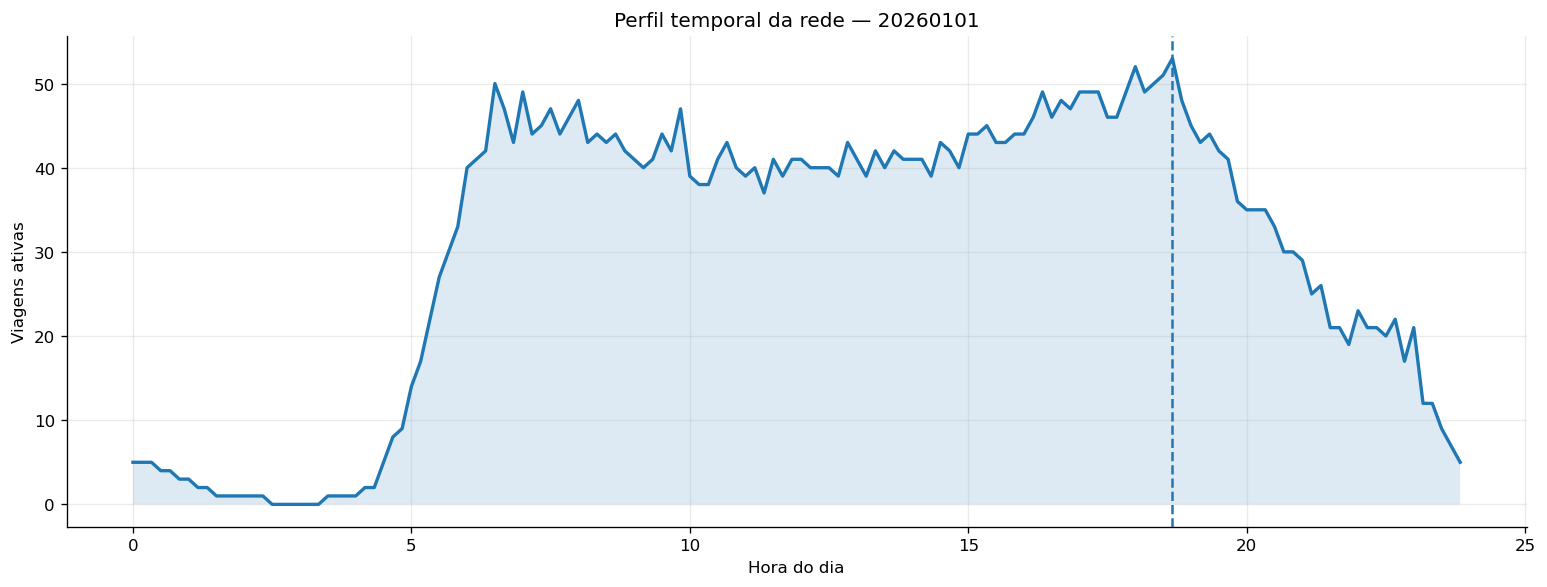

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(nts["hour"], nts["num_trips"], linewidth=2)
ax.fill_between(nts["hour"], nts["num_trips"], alpha=0.15)
ax.axvline(peak_row["hour"], linestyle="--", linewidth=1.5)
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Viagens ativas")
ax.set_title(f"Perfil temporal da rede — {analysis_date}")
plt.tight_layout()
plt.show()

## 4 — Paradas

In [12]:
stops_gdf = build_stop_stats_gdf(
    feed,
    analysis_date,
    headway_start=HEADWAY_START,
    headway_end=HEADWAY_END,
    split_directions=SPLIT_DIRECTIONS_STOPS,
)

display(
    stops_gdf
    .nlargest(10, "num_trips")
    [["stop_name", "num_trips", "mean_headway", "frequency_per_hour"]]
    .style
    .format({"mean_headway": "{:.1f}", "frequency_per_hour": "{:.1f}"})
    .hide(axis="index")
    .set_caption("Top 10 paradas por número de viagens")
)

stop_name,num_trips,mean_headway,frequency_per_hour
"Avenida Júlia Kubitschek, 20",675.000000,1.3,45.6
Avenida Júlia Kubitsheck 587,634.000000,1.4,43.4
Avenida Júlia Kubitschek 562,624.000000,1.4,42.9
"Av. Júlia Kubitscheck, 125",601.000000,1.5,40.5
"Rua Silva Jardim, 9",601.000000,1.5,40.4
"Avenida Júlia Kubitschek, 26",593.000000,1.5,40.7
"Avenida Teixeira e Souza, 2031",584.000000,1.5,39.6
"Avenida Teixeira e Souza, 1600",584.000000,1.5,39.9
Avenida Teixeira e Souza 202,584.000000,1.5,39.9
Avenida Teixeira e Souza 2,584.000000,1.5,40.0


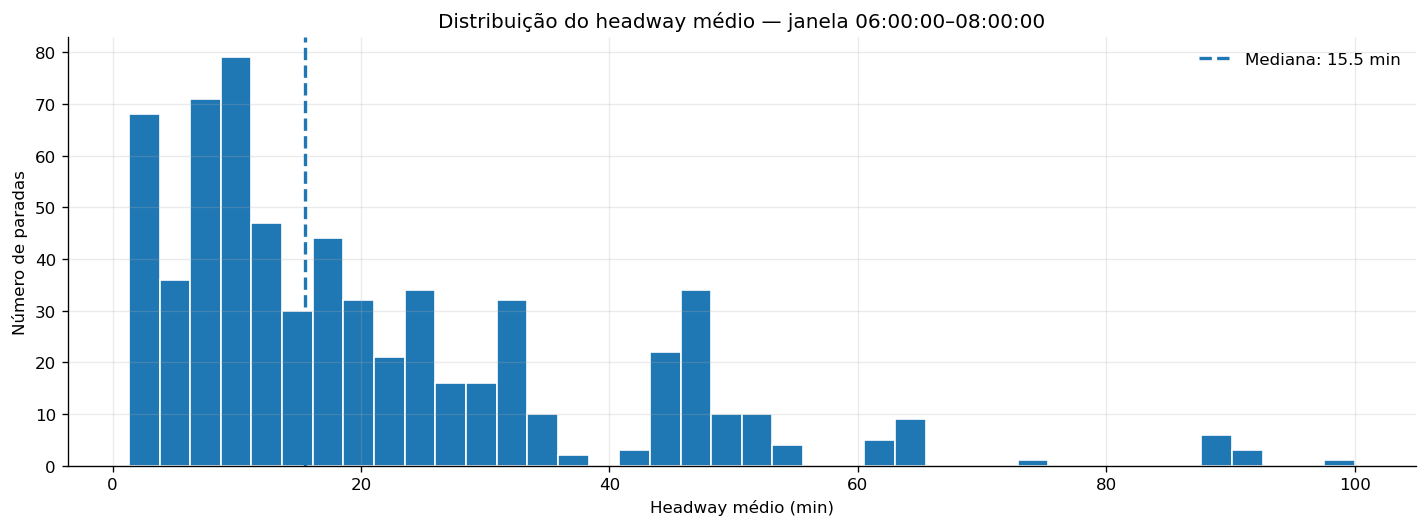

In [13]:
fig, ax = plt.subplots(figsize=(12, 4.5))
vals = stops_gdf["mean_headway"].dropna()
ax.hist(vals, bins=40, edgecolor="white")
ax.axvline(vals.median(), linestyle="--", linewidth=2, label=f"Mediana: {vals.median():.1f} min")
ax.set_xlabel("Headway médio (min)")
ax.set_ylabel("Número de paradas")
ax.set_title(f"Distribuição do headway médio — janela {HEADWAY_START}–{HEADWAY_END}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [14]:
plot_df = stops_gdf.loc[stops_gdf["frequency_per_hour"].notna()].copy()

fig = px.scatter_map(
    plot_df,
    lat="stop_lat",
    lon="stop_lon",
    color="frequency_per_hour",
    size="frequency_per_hour",
    size_max=14,
    hover_name="stop_name",
    hover_data={
        "num_trips": True,
        "mean_headway": ":.1f",
        "frequency_per_hour": ":.1f",
        "stop_lat": False,
        "stop_lon": False,
    },
    zoom=11,
    title=f"Frequência por parada ({HEADWAY_START}–{HEADWAY_END})",
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=45, b=0))
fig.show()

In [15]:
fig = px.scatter_map(
    stops_gdf.loc[stops_gdf["mean_headway"].notna()].copy(),
    lat="stop_lat",
    lon="stop_lon",
    color="mean_headway",
    size="num_trips",
    size_max=12,
    hover_name="stop_name",
    hover_data={
        "num_trips": True,
        "mean_headway": ":.1f",
        "stop_lat": False,
        "stop_lon": False,
    },
    zoom=11,
    title=f"Headway médio por parada ({HEADWAY_START}–{HEADWAY_END})",
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=45, b=0))
fig.show()

## 5 — Sobreposição interparadas

Esta seção foi rebaixada de “corredor” para **proxy interparadas**, porque o método não reconstrói o eixo físico real da linha ao longo da rua.  
Ele apenas identifica pares consecutivos de paradas nas viagens ativas e conta quantas rotas usam cada ligação. Isso é útil para ver **concentração topológica de serviço**, mas não deve ser lido como mapeamento preciso de infraestrutura linear.

In [16]:
seg_gdf = build_interstop_proxy(feed, active_trip_ids)

display(
    seg_gdf
    .nlargest(15, "n_routes")
    [["stop_a", "stop_b", "n_routes", "n_trips", "proxy_note"]]
    .style
    .hide(axis="index")
    .set_caption("Ligações interparadas com maior sobreposição")
)

print(f"Ligações interparadas identificadas: {len(seg_gdf):,}")
print(f"Máximo de rotas sobre a mesma ligação: {seg_gdf['n_routes'].max():.0f}")
print(f"Máximo de viagens sobre a mesma ligação: {seg_gdf['n_trips'].max():.0f}")

stop_a,stop_b,n_routes,n_trips,proxy_note
s000973,s000123,21,624,proxy interparadas
s000123,s001846,21,624,proxy interparadas
s000973,s000200,21,337,proxy interparadas
s000200,s001752,21,601,proxy interparadas
s001604,s000687,21,338,proxy interparadas
s000687,s001869,21,338,proxy interparadas
s001869,s000973,21,338,proxy interparadas
s000168,s001794,18,551,proxy interparadas
s001846,s000168,18,593,proxy interparadas
s002045,s000463,17,584,proxy interparadas


Ligações interparadas identificadas: 1,004
Máximo de rotas sobre a mesma ligação: 21
Máximo de viagens sobre a mesma ligação: 624


In [17]:
# ── segmentos mais carregados ──────────────────────────────────────────────
top_seg = seg_gdf.nlargest(500, "n_routes").copy().to_crs(4326)

# centro do mapa
xmin, ymin, xmax, ymax = top_seg.total_bounds
center_lat = (ymin + ymax) / 2
center_lon = (xmin + xmax) / 2

# domínio da variável
cmin = float(top_seg["n_routes"].min())
cmax = float(top_seg["n_routes"].max())
if cmin == cmax:
    cmax = cmin + 1.0  # evita divisão por zero em caso degenerado

colorscale = "Viridis"

def _norm(v, vmin, vmax):
    return 0.5 if vmax <= vmin else (v - vmin) / (vmax - vmin)

def _line_color(v, vmin, vmax, colorscale):
    t = min(max(_norm(v, vmin, vmax), 0), 1)
    return sample_colorscale(colorscale, [t])[0]

def _line_width(v, vmin, vmax, wmin=1.5, wmax=6.0):
    t = _norm(v, vmin, vmax)
    return wmin + t * (wmax - wmin)

fig = go.Figure()

# ── linhas com cor contínua manual ─────────────────────────────────────────
for idx, row in top_seg.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue

    n_routes = float(row["n_routes"])
    color = _line_color(n_routes, cmin, cmax, colorscale)
    width = _line_width(n_routes, cmin, cmax)

    if geom.geom_type == "LineString":
        xs, ys = geom.xy
        fig.add_trace(
            go.Scattermap(
                lon=list(xs),
                lat=list(ys),
                mode="lines",
                line=dict(color=color, width=width),
                customdata=[[row["n_routes"]]] * len(xs),
                hovertemplate="Nº de rotas: %{customdata[0]}<extra></extra>",
                showlegend=False,
            )
        )

    elif geom.geom_type == "MultiLineString":
        for part in geom.geoms:
            xs, ys = part.xy
            fig.add_trace(
                go.Scattermap(
                    lon=list(xs),
                    lat=list(ys),
                    mode="lines",
                    line=dict(color=color, width=width),
                    customdata=[[row["n_routes"]]] * len(xs),
                    hovertemplate="Nº de rotas: %{customdata[0]}<extra></extra>",
                    showlegend=False,
                )
            )

# ── traço invisível só para materializar a colorbar contínua ─────────────
fig.add_trace(
    go.Scattermap(
        lon=[center_lon, center_lon],
        lat=[center_lat, center_lat],
        mode="markers",
        marker=dict(
            size=0.01,
            color=[cmin, cmax],
            colorscale=colorscale,
            cmin=cmin,
            cmax=cmax,
            showscale=True,
            colorbar=dict(
                title="Nº de rotas",
                thickness=18,
                len=0.75,
                x=0.98,
                y=0.5,
            ),
            opacity=0,
        ),
        hoverinfo="skip",
        showlegend=False,
    )
)

fig.update_layout(
    title="Proxy de sobreposição interparadas por número de rotas",
    height=750,
    margin=dict(l=0, r=0, t=50, b=0),
    map=dict(
        style="carto-positron",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=11,
    ),
)

fig.show()

## 6 — Produção por viagem e por rota

In [18]:
route_summary = build_route_summary(trip_metrics)
window_summary = build_trip_window_summary(trip_metrics, TIME_WINDOWS)

grand = pd.DataFrame(
    {
        "Indicador": [
            "Rotas ativas",
            "Viagens ativas",
            "VKT total (km)",
            "Km médios por viagem",
            "Duração média por viagem (min)",
            "Velocidade média por viagem (km/h)",
            "Horas-veículo totais",
        ],
        "Valor": [
            f"{route_summary['route_id'].nunique():,}",
            f"{len(trip_metrics):,}",
            f"{trip_metrics['distance_km'].sum():,.0f}",
            f"{trip_metrics['distance_km'].mean():.2f}",
            f"{trip_metrics['duration_h'].mean() * 60:.1f}",
            f"{trip_metrics['speed_kmh'].mean():.1f}",
            f"{trip_metrics['duration_h'].sum():,.0f}",
        ],
    }
)

display(grand.style.hide(axis="index").set_caption("Totais do dia"))
display(
    route_summary.head(25).style
    .format({
        "km_total": "{:,.1f}",
        "km_medio": "{:.2f}",
        "duracao_media_min": "{:.1f}",
        "vel_media_kmh": "{:.1f}",
    })
    .hide(axis="index")
    .set_caption("Resumo por rota")
)
display(
    window_summary.style
    .format({
        "km_total": "{:,.1f}",
        "duracao_h": "{:,.1f}",
    })
    .set_caption("Resumo por faixa horária")
)

Indicador,Valor
Rotas ativas,23
Viagens ativas,781
VKT total (km),"11,504"
Km médios por viagem,14.73
Duração média por viagem (min),46.6
Velocidade média por viagem (km/h),17.7
Horas-veículo totais,607


route_id,route_short_name,route_long_name,viagens,km_total,km_medio,duracao_media_min,vel_media_kmh
r321,321,São Cristóvão / Tangará,216,"2,534.4",11.73,47.0,15.5
r355,355,Botafogo / Chavão,62,"1,335.4",21.54,60.0,21.7
r316,316,São Cristóvão / Santo Antônio,29,"1,192.5",41.12,92.2,27.8
r352,352,São Cristóvão / Santo Antônio,21,"1,071.5",51.02,105.7,29.2
r302,302,São Cristóvão / Agrisa,18,"1,005.3",55.85,112.9,30.7
r328,328,São Cristóvão / Peró,77,895.4,11.63,40.9,17.4
r309,309,São Cristóvão / Parque Eldorado,50,632.6,12.65,43.1,18.1
r311,311,Contorno / Vila do Sol,52,482.1,9.27,32.1,18.5
r338,338,São Cristóvão / Guriri,22,312.9,14.22,45.7,19.3
r303,303,Contorno / Jardim Caiçara,46,252.5,5.49,26.7,12.6


,trips,km_total,duracao_h
window,,,
Madrugada,16.000000,492.7,14.4
Manhã Pico,186.000000,"2,809.5",140.8
Entrepico,305.000000,"4,308.6",243.6
Tarde Pico,183.000000,"2,648.3",148.4
Noite,91.000000,"1,245.0",59.7


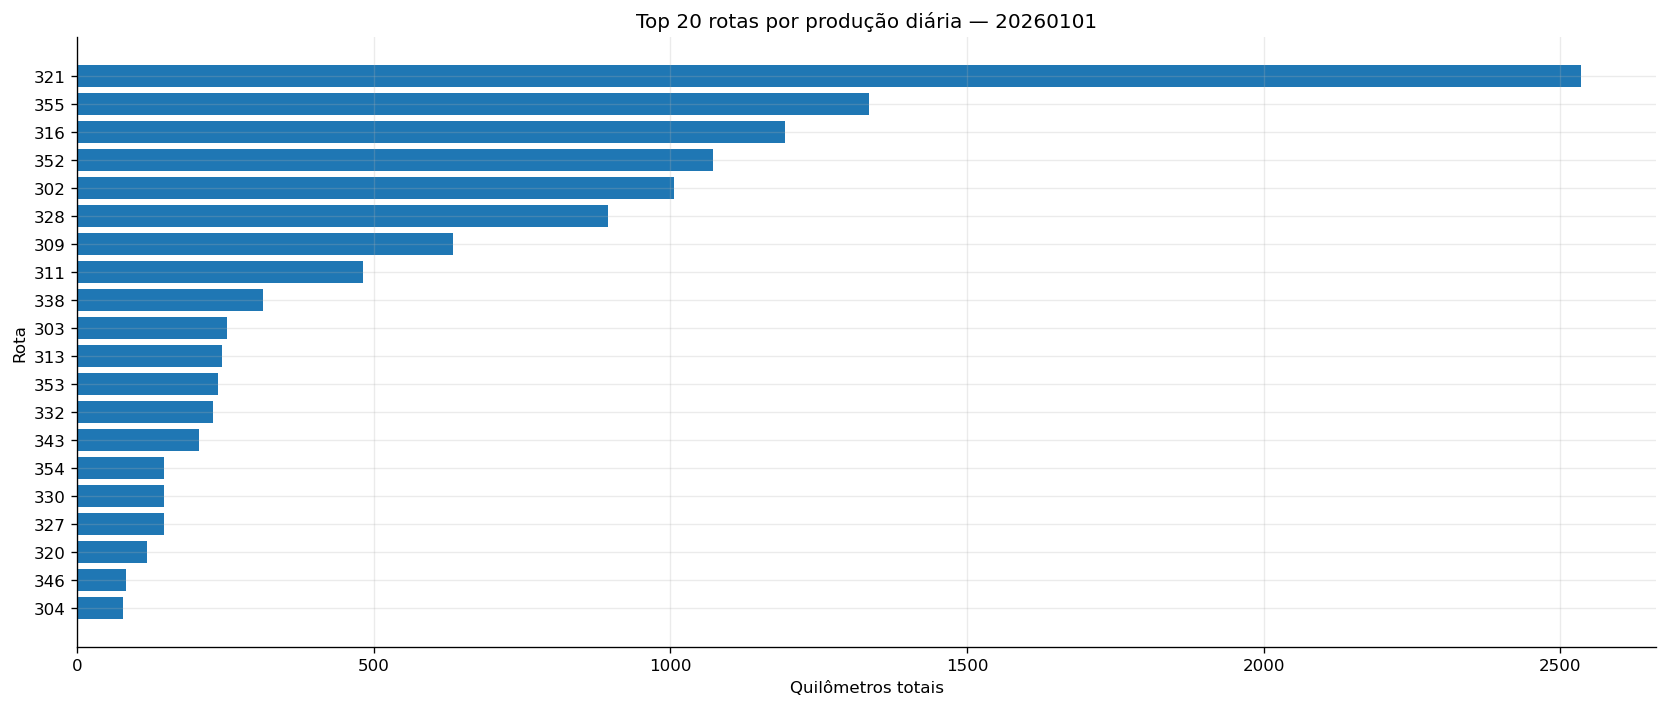

In [19]:
top20 = route_summary.head(20).copy()

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top20["route_short_name"].fillna(top20["route_id"]), top20["km_total"])
ax.invert_yaxis()
ax.set_xlabel("Quilômetros totais")
ax.set_ylabel("Rota")
ax.set_title(f"Top 20 rotas por produção diária — {analysis_date}")
plt.tight_layout()
plt.show()

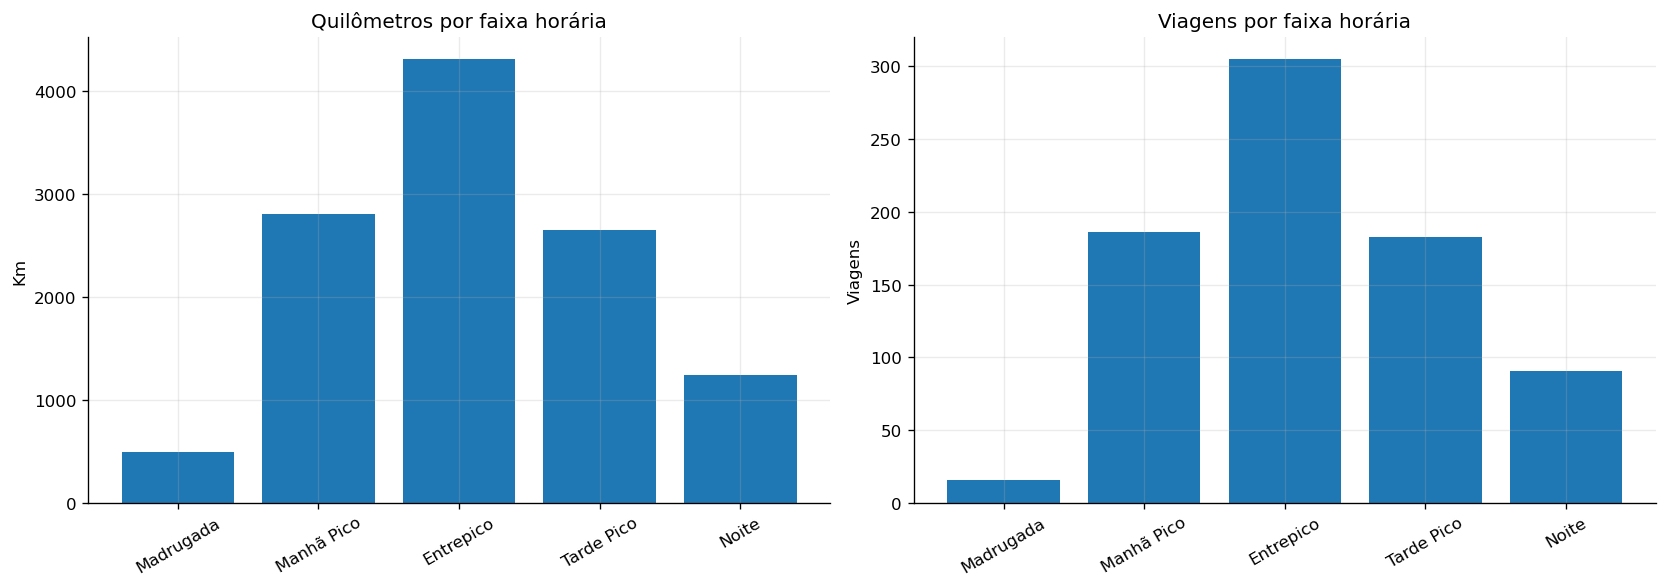

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(window_summary.index, window_summary["km_total"])
axes[0].set_title("Quilômetros por faixa horária")
axes[0].set_ylabel("Km")

axes[1].bar(window_summary.index, window_summary["trips"])
axes[1].set_title("Viagens por faixa horária")
axes[1].set_ylabel("Viagens")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 7 — Diagnósticos

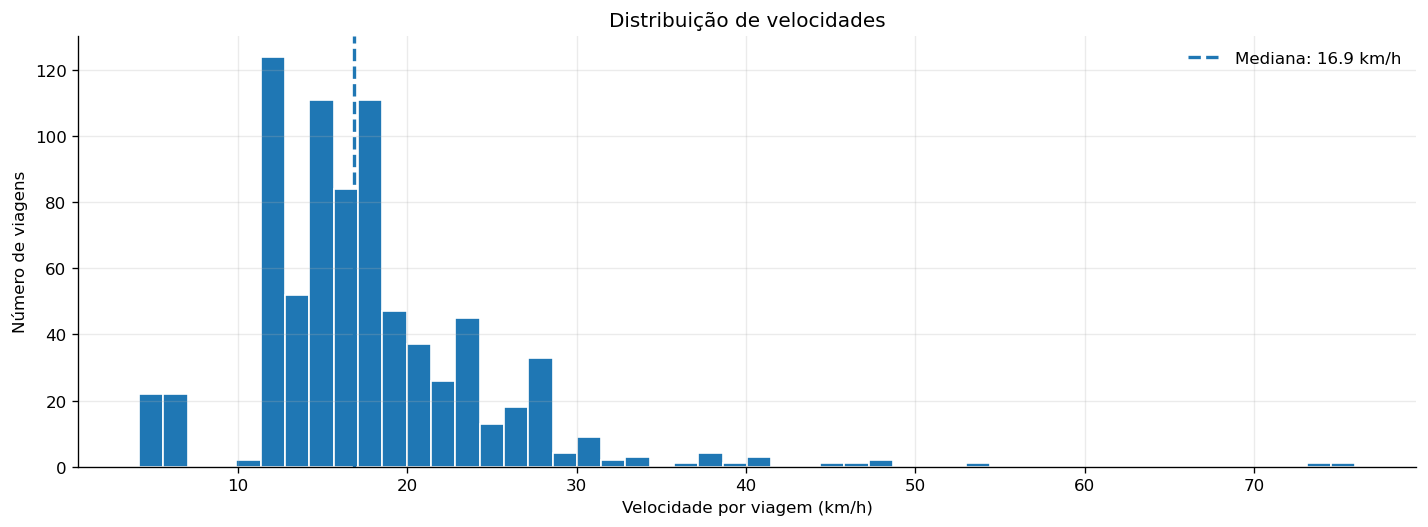

route_id,route_short_name,trip_id,distance_km,duration_h,speed_kmh


In [21]:
fig, ax = plt.subplots(figsize=(12, 4.5))
spd = trip_metrics["speed_kmh"].dropna()
ax.hist(spd, bins=50, edgecolor="white")
ax.axvline(spd.median(), linestyle="--", linewidth=2, label=f"Mediana: {spd.median():.1f} km/h")
ax.set_xlabel("Velocidade por viagem (km/h)")
ax.set_ylabel("Número de viagens")
ax.set_title("Distribuição de velocidades")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(
    trip_metrics.loc[trip_metrics["speed_kmh"] > 80, [
        "route_id", "route_short_name", "trip_id", "distance_km", "duration_h", "speed_kmh"
    ]]
    .sort_values("speed_kmh", ascending=False)
    .head(15)
    .style
    .format({"distance_km": "{:.2f}", "duration_h": "{:.2f}", "speed_kmh": "{:.1f}"})
    .hide(axis="index")
    .set_caption("Viagens com velocidade muito alta (> 80 km/h)")
)

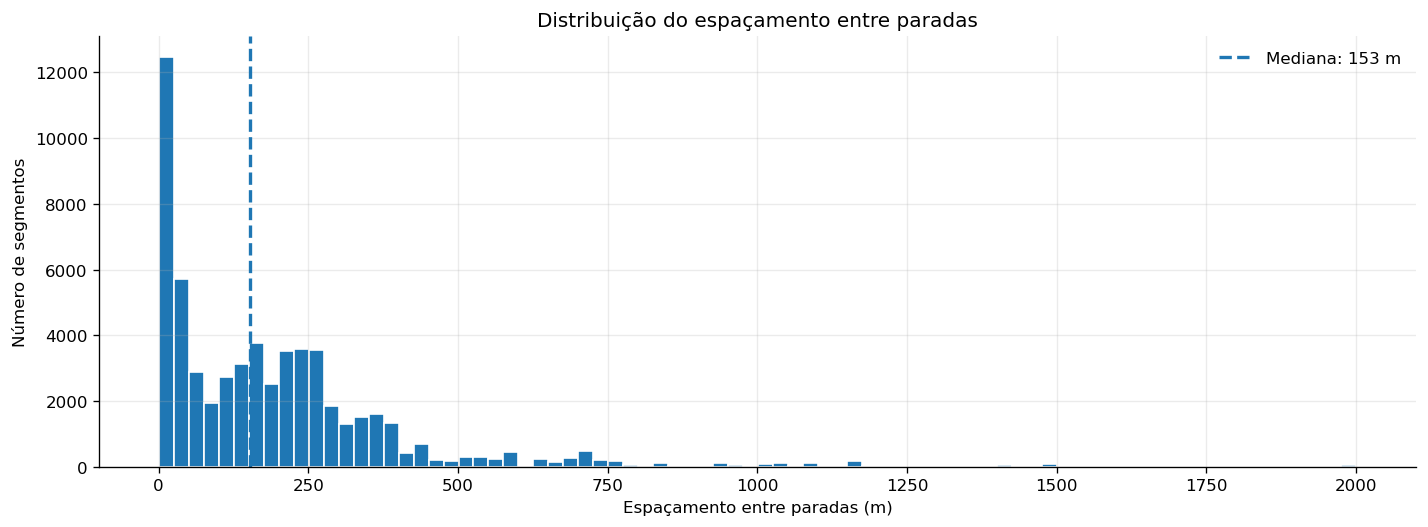

Indicador,Valor
Espaçamento mediano (m),153
Segmentos > 2 km,58 (0.1%)
Segmentos < 100 m,"22,837 (38.9%)"


In [22]:
spacing = build_stop_spacing(feed, active_trip_ids, distance_scale)

fig, ax = plt.subplots(figsize=(12, 4.5))
seg_m = spacing["segment_m"].clip(upper=2000)
ax.hist(seg_m, bins=80, edgecolor="white")
ax.axvline(seg_m.median(), linestyle="--", linewidth=2, label=f"Mediana: {seg_m.median():.0f} m")
ax.set_xlabel("Espaçamento entre paradas (m)")
ax.set_ylabel("Número de segmentos")
ax.set_title("Distribuição do espaçamento entre paradas")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

spacing_summary = pd.DataFrame(
    {
        "Indicador": [
            "Espaçamento mediano (m)",
            "Segmentos > 2 km",
            "Segmentos < 100 m",
        ],
        "Valor": [
            f"{spacing['segment_m'].median():.0f}",
            f"{(spacing['segment_m'] > 2000).sum():,} ({(spacing['segment_m'] > 2000).mean() * 100:.1f}%)",
            f"{(spacing['segment_m'] < 100).sum():,} ({(spacing['segment_m'] < 100).mean() * 100:.1f}%)",
        ],
    }
)
display(spacing_summary.style.hide(axis="index").set_caption("Síntese do espaçamento entre paradas"))

In [23]:
dur_plot = trip_metrics.copy()
dur_plot["duration_min"] = dur_plot["duration_h"] * 60
top_routes = dur_plot["route_short_name"].fillna(dur_plot["route_id"]).value_counts().head(15).index
dur_plot["route_label"] = dur_plot["route_short_name"].fillna(dur_plot["route_id"])
dur_plot = dur_plot.loc[dur_plot["route_label"].isin(top_routes)]

fig = px.box(
    dur_plot,
    x="route_label",
    y="duration_min",
    title="Duração das viagens por rota (top 15 por número de viagens)",
    labels={"route_label": "Rota", "duration_min": "Duração (min)"},
)
fig.update_layout(height=500, showlegend=False)
fig.show()

In [ ]:
checks = build_feed_checks(feed)
display(
    checks.style
    .hide(axis="index")
    .set_caption("Diagnóstico estrutural do feed")
)

Verificação,Contagem,Status
Viagens sem stop_times,0,ok
Paradas sem visitas,0,ok
Rotas sem viagens,0,ok
Shapes faltando,0,ok
stop_times sem arrival_time,0,ok
shape_dist_traveled nulo,0,ok


: 

## Notas finais

- As métricas de **VKT** e **velocidade** passam a depender da hipótese de unidade explicitada na seção 2.
- A leitura espacial de “corredores” foi substituída por um **proxy interparadas**, mais modesto e metodologicamente mais correto para este tipo de notebook.
- O agrupamento analítico principal foi mantido em **`route_id`**, usando `route_short_name` apenas como rótulo de exibição.
- Onde fizer sentido avançar, o próximo passo é separar o que é **QA do feed**, **perfil operacional** e **proxy espacial** em arquivos auxiliares ou num pacote leve.